# Linear Regression Exercise

## Use linear regression on the *bodyfat* dataset

We are going to follow the same pipeline than in the lab session but now with a simple dataset.  

- [ ] Visualize your dataset. Does it have anything strange?
- [ ] Split your dataset in train and test.
- [ ] Design a pre-processing for your dataset and apply it to your partitions.
- [ ] Train a Linear Regression model.
- [ ] Train a Ridge Regression model with cross-validation.  
- [ ] Train a Lasso Regression model with cross-validation.  
- [ ] Compare your three models using cross-validation metrics and looking into their weights. Do they show strong differences?
- [ ] Compute the generalization performance of the best model.

In [164]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy import stats


pd.set_option('display.precision', 3)
np.set_printoptions(precision=3)

### Dataset visualization
Histograms, scatter matrix and tables are used to visualize the data.

In [165]:
bodyfat_data = pd.read_csv("bodyfatdata.txt",
                        sep=r"\s+", engine="python",
                        names=['triceps', 'thigh', 'midarm', 'bodyfat'])

print(bodyfat_data.shape)
bodyfat_data.describe()

(20, 4)


,triceps,thigh,midarm,bodyfat
count,20.000,20.000,20.000,20.000
mean,25.305,51.170,27.620,20.195
std,5.023,5.235,3.647,5.106
min,14.600,42.200,21.300,11.700
25%,21.500,47.775,24.750,17.050
50%,25.550,52.000,27.900,21.200
75%,29.900,54.625,30.025,24.275
max,31.400,58.600,37.000,27.200


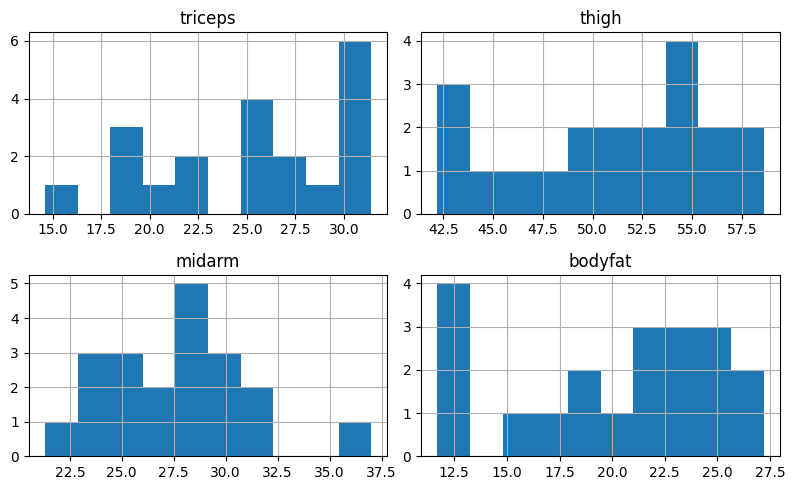

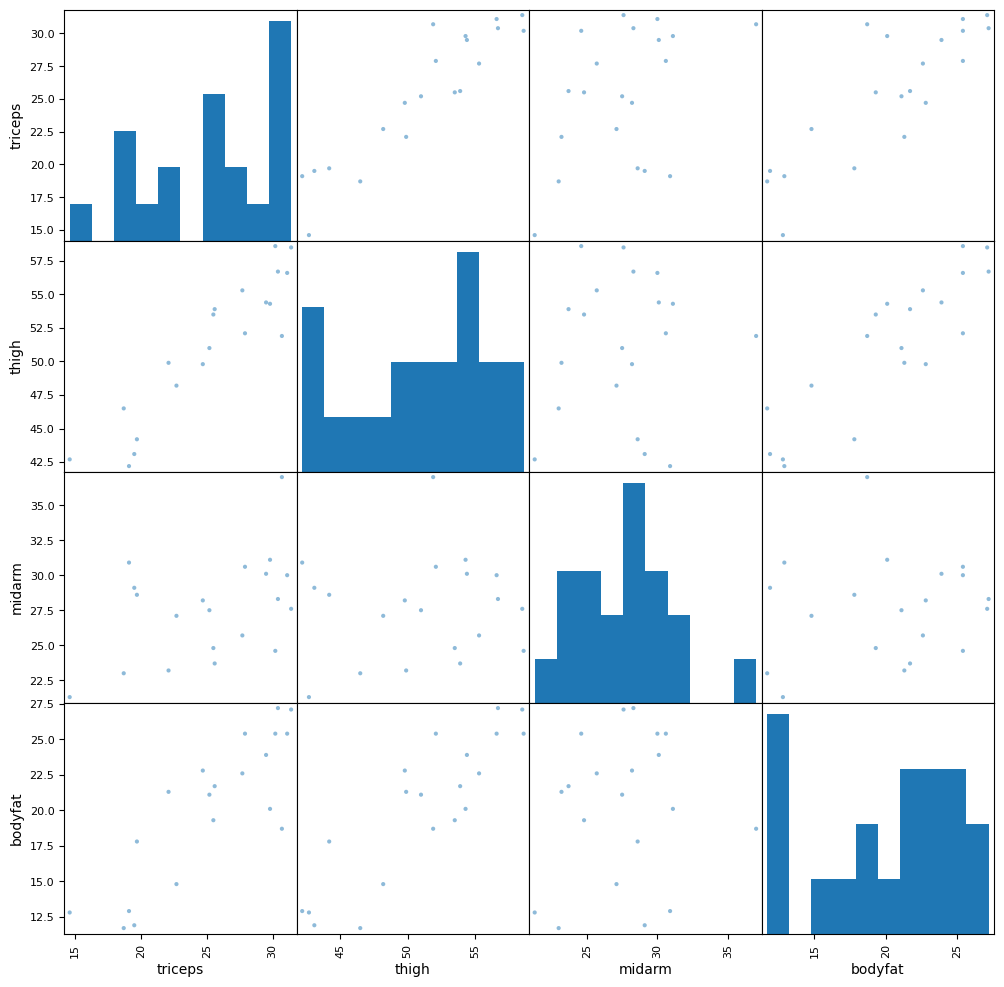

In [166]:
bodyfat_data.head().sort_values(by='bodyfat')

# Histograms
bodyfat_data.hist(figsize=(8, 5))
plt.tight_layout()
plt.show()

# Scatter matrix
scatter_matrix(bodyfat_data, figsize=(12, 12))
plt.show()


We can see that there is a correlation between variables triceps and thigh, triceps and bodyfat, thigh and bodyfat.

In [167]:
bodyfat_data.isna().sum() # there are no missing values

triceps    0
thigh      0
midarm     0
bodyfat    0
dtype: int64

### Split of the dataset

In [168]:
X = bodyfat_data.drop(columns="bodyfat")
y = bodyfat_data["bodyfat"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(16, 3) (4, 3)


### Pre-processing

All predictor variables are numeric, so a simple numeric pipeline is enough: median imputation plus standardization.

In [169]:
numeric_preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_train_processed = numeric_preprocessing.fit_transform(X_train)
X_test_processed = numeric_preprocessing.transform(X_test)

X_train_processed = pd.DataFrame(X_train_processed, columns=X_train.columns, index=X_train.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=X_test.columns, index=X_test.index)

display(X_train_processed.head())
display(X_train_processed.describe())

,triceps,thigh,midarm
8,-0.605,-0.242,-1.129
5,0.092,0.570,-0.999
11,1.048,1.139,0.202
3,0.929,0.651,0.933
18,-0.485,-0.588,-0.111


,triceps,thigh,midarm
count,1.600e+01,1.600e+01,1.600e+01
mean,8.327e-17,1.041e-16,4.718e-16
std,1.033e+00,1.033e+00,1.033e+00
min,-2.099e+00,-1.806e+00,-1.625e+00
25%,-7.245e-01,-6.740e-01,-7.831e-01
50%,8.216e-02,1.841e-01,6.526e-03
75%,9.585e-01,7.020e-01,6.853e-01
max,1.247e+00,1.504e+00,2.473e+00


### Linear Regression Model

Train -> MSE: 4.994 | MAE: 1.844 | R2: 0.789
Test  -> MSE: 5.188 | MAE: 1.840 | R2: 0.818


,coefficient
triceps,28.315
thigh,-19.726
midarm,-10.989


Intercept: 19.993750000000006


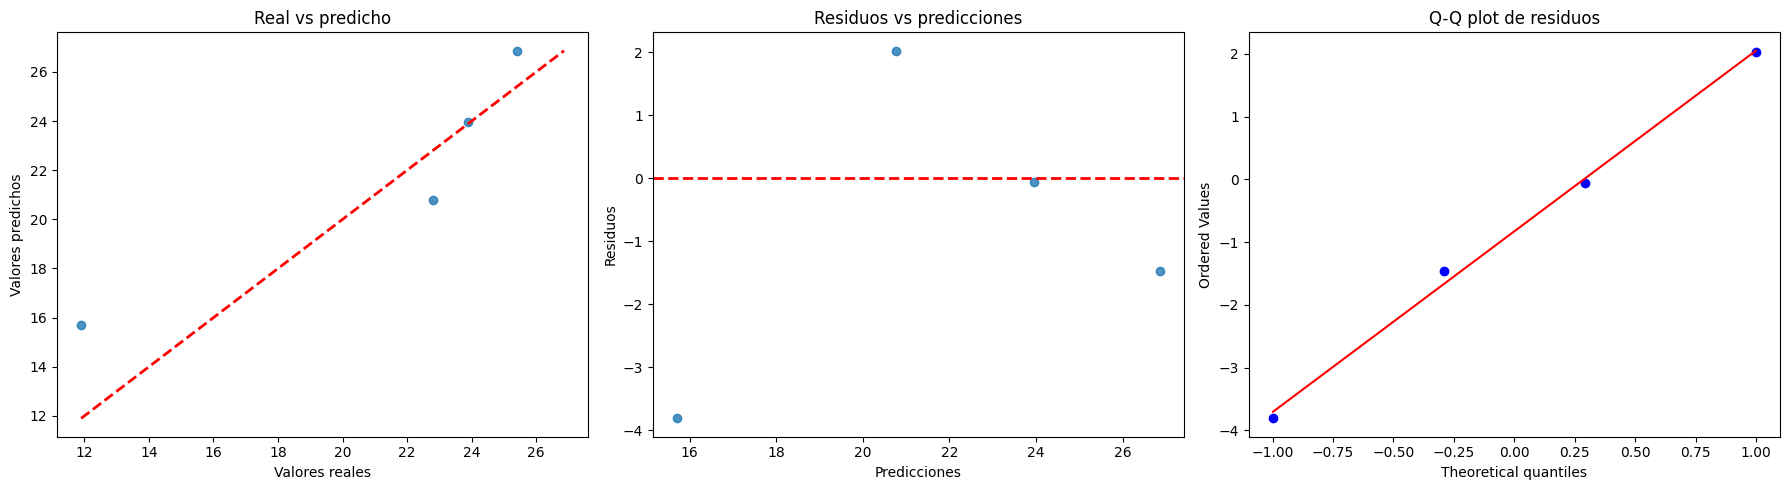

In [170]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train_processed, y_train)

y_train_pred = lr.predict(X_train_processed)
y_test_pred = lr.predict(X_test_processed)
residuals_test = y_test - y_test_pred

print('Train -> MSE: {:.3f} | MAE: {:.3f} | R2: {:.3f}'.format(
    mean_squared_error(y_train, y_train_pred),
    mean_absolute_error(y_train, y_train_pred),
    r2_score(y_train, y_train_pred)
))
print('Test  -> MSE: {:.3f} | MAE: {:.3f} | R2: {:.3f}'.format(
    mean_squared_error(y_test, y_test_pred),
    mean_absolute_error(y_test, y_test_pred),
    r2_score(y_test, y_test_pred)
))

coef_df = pd.Series(lr.coef_, index=X_train.columns, name='coefficient')
display(coef_df.to_frame())
print('Intercept:', lr.intercept_)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
axes[0].scatter(y_test, y_test_pred, alpha=0.8)
axes[0].plot(lims, lims, 'r--', linewidth=2)
axes[0].set_title('Real vs predicho')
axes[0].set_xlabel('Valores reales')
axes[0].set_ylabel('Valores predichos')

axes[1].scatter(y_test_pred, residuals_test, alpha=0.8)
axes[1].axhline(0, color='r', linestyle='--', linewidth=2)
axes[1].set_title('Residuos vs predicciones')
axes[1].set_xlabel('Predicciones')
axes[1].set_ylabel('Residuos')

stats.probplot(residuals_test, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q plot de residuos')

plt.tight_layout()
plt.show()

### Ridge Regression Model with cross-validation

Best alpha (CV): 0.521401
Train -> MSE: 5.703 | MAE: 1.981 | R2: 0.759
Test  -> MSE: 4.457 | MAE: 1.737 | R2: 0.843


,coefficient
triceps,2.355
thigh,2.091
midarm,-0.601


Intercept: 19.993750000000002


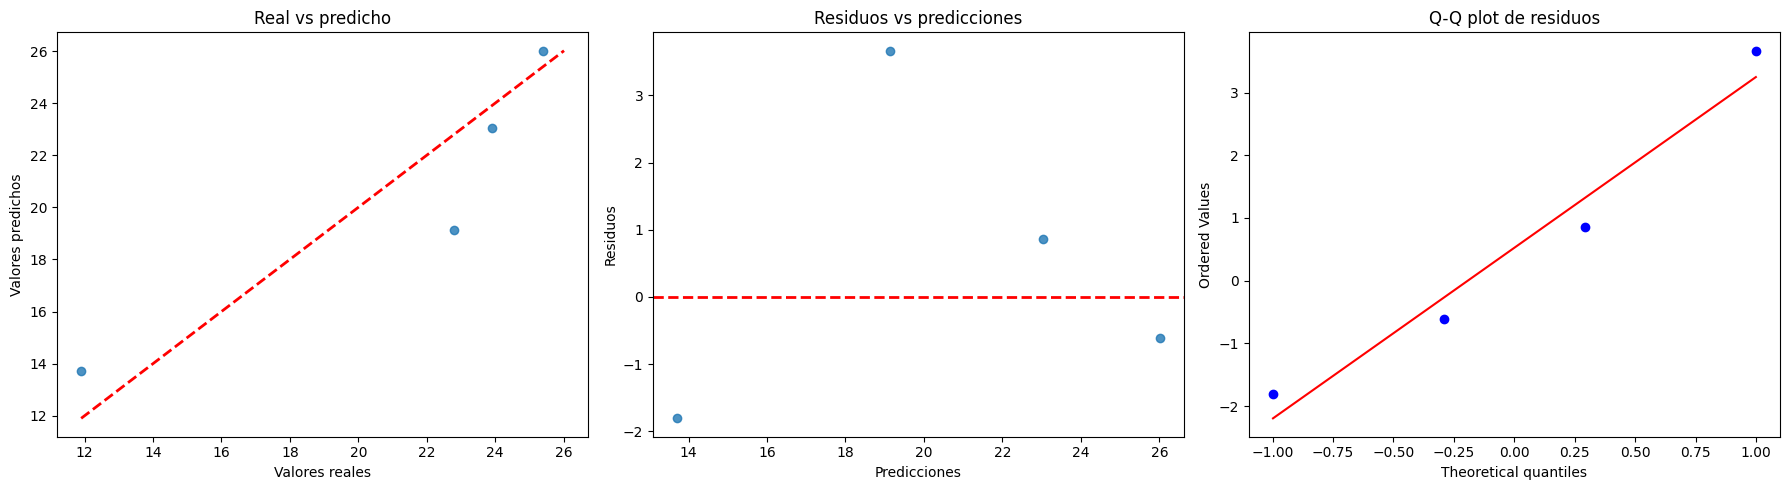

In [171]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

alphas = np.logspace(-4, 4, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_processed, y_train)

y_train_pred = ridge_cv.predict(X_train_processed)
y_test_pred = ridge_cv.predict(X_test_processed)
residuals_test = y_test - y_test_pred

print(f'Best alpha (CV): {ridge_cv.alpha_:.6f}')
print('Train -> MSE: {:.3f} | MAE: {:.3f} | R2: {:.3f}'.format(
    mean_squared_error(y_train, y_train_pred),
    mean_absolute_error(y_train, y_train_pred),
    r2_score(y_train, y_train_pred)
))
print('Test  -> MSE: {:.3f} | MAE: {:.3f} | R2: {:.3f}'.format(
    mean_squared_error(y_test, y_test_pred),
    mean_absolute_error(y_test, y_test_pred),
    r2_score(y_test, y_test_pred)
))

coef_df = pd.Series(ridge_cv.coef_, index=X_train.columns, name='coefficient')
display(coef_df.to_frame())
print('Intercept:', ridge_cv.intercept_)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
axes[0].scatter(y_test, y_test_pred, alpha=0.8)
axes[0].plot(lims, lims, 'r--', linewidth=2)
axes[0].set_title('Real vs predicho')
axes[0].set_xlabel('Valores reales')
axes[0].set_ylabel('Valores predichos')

axes[1].scatter(y_test_pred, residuals_test, alpha=0.8)
axes[1].axhline(0, color='r', linestyle='--', linewidth=2)
axes[1].set_title('Residuos vs predicciones')
axes[1].set_xlabel('Predicciones')
axes[1].set_ylabel('Residuos')

stats.probplot(residuals_test, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q plot de residuos')

plt.tight_layout()
plt.show()


### Lasso Regression Model with cross-validation

Best alpha (CV): 0.191791
Train -> MSE: 5.819 | MAE: 1.999 | R2: 0.754
Test  -> MSE: 4.651 | MAE: 1.748 | R2: 0.837


,coefficient
triceps,0.852
thigh,3.235
midarm,0.000


Intercept: 19.993750000000002


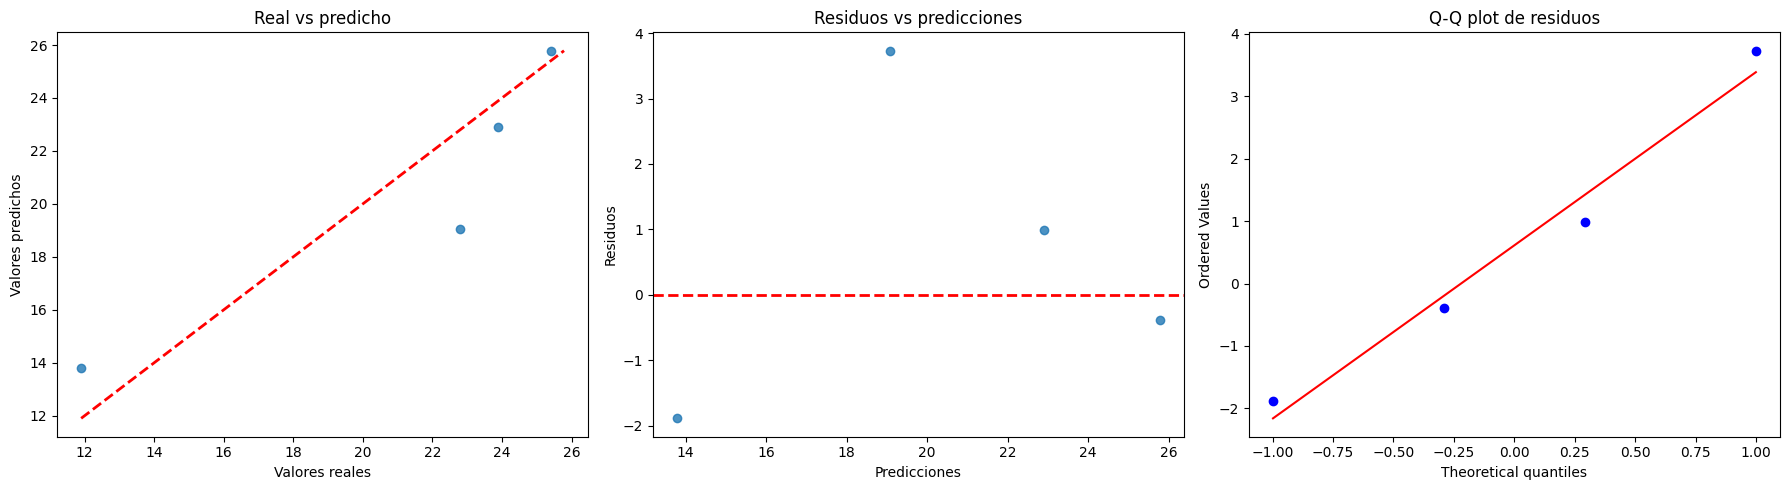

In [172]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

alphas = np.logspace(-4, 1, 100)
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_processed, y_train)

y_train_pred = lasso_cv.predict(X_train_processed)
y_test_pred = lasso_cv.predict(X_test_processed)
residuals_test = y_test - y_test_pred

print(f'Best alpha (CV): {lasso_cv.alpha_:.6f}')
print('Train -> MSE: {:.3f} | MAE: {:.3f} | R2: {:.3f}'.format(
    mean_squared_error(y_train, y_train_pred),
    mean_absolute_error(y_train, y_train_pred),
    r2_score(y_train, y_train_pred)
))
print('Test  -> MSE: {:.3f} | MAE: {:.3f} | R2: {:.3f}'.format(
    mean_squared_error(y_test, y_test_pred),
    mean_absolute_error(y_test, y_test_pred),
    r2_score(y_test, y_test_pred)
))

coef_df = pd.Series(lasso_cv.coef_, index=X_train.columns, name='coefficient')
display(coef_df.to_frame())
print('Intercept:', lasso_cv.intercept_)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
axes[0].scatter(y_test, y_test_pred, alpha=0.8)
axes[0].plot(lims, lims, 'r--', linewidth=2)
axes[0].set_title('Real vs predicho')
axes[0].set_xlabel('Valores reales')
axes[0].set_ylabel('Valores predichos')

axes[1].scatter(y_test_pred, residuals_test, alpha=0.8)
axes[1].axhline(0, color='r', linestyle='--', linewidth=2)
axes[1].set_title('Residuos vs predicciones')
axes[1].set_xlabel('Predicciones')
axes[1].set_ylabel('Residuos')

stats.probplot(residuals_test, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q plot de residuos')

plt.tight_layout()
plt.show()


### Comparation of the models
Compare the three models using cross-validation metrics and looking into their weights. Do they show strong differences?

,Train_MSE,Test_MSE,Train_MAE,Test_MAE,Train_R2,Test_R2
Model,,,,,,
RidgeCV,5.703,4.457,1.981,1.737,0.759,0.843
LassoCV,5.819,4.651,1.999,1.748,0.754,0.837
Linear,4.994,5.188,1.844,1.840,0.789,0.818


,Linear,RidgeCV,LassoCV
triceps,28.315,2.355,0.852
thigh,-19.726,2.091,3.235
midarm,-10.989,-0.601,0.000


Relative L2 diff (Linear vs Ridge): 0.979
Relative L2 diff (Linear vs Lasso): 1.034
Relative L2 diff (Ridge vs Lasso): 0.618
Features with zero weight in Lasso: 1


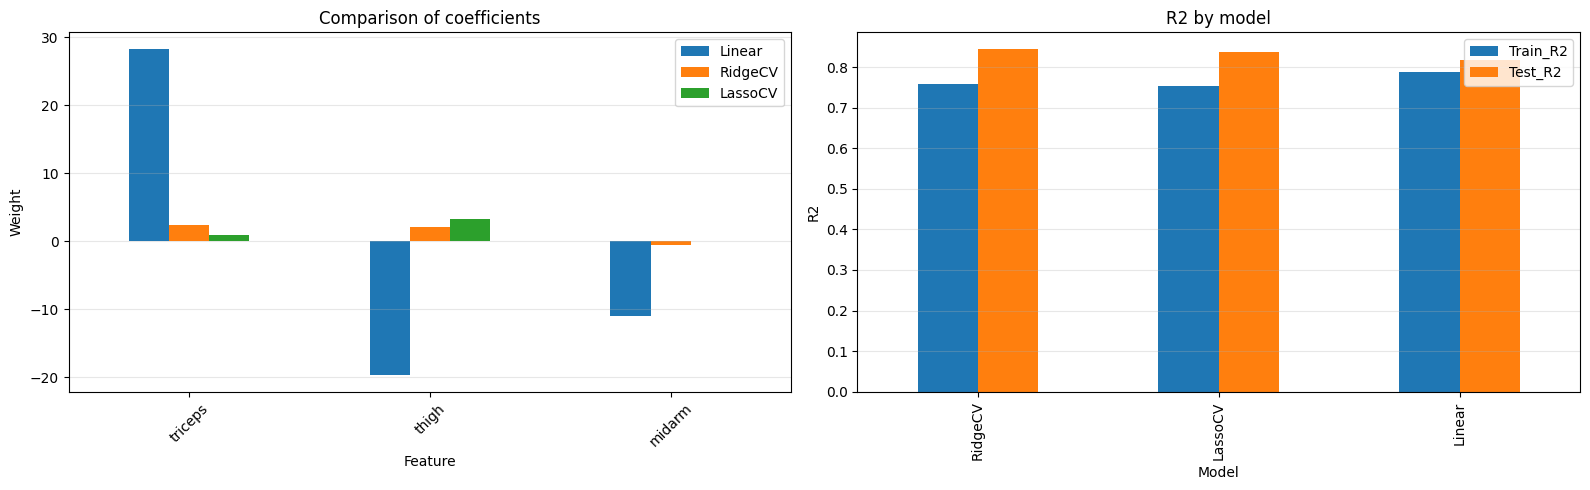

In [173]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = {
    'Linear': lr,
    'RidgeCV': ridge_cv,
    'LassoCV': lasso_cv
}

rows = []
for name, model in models.items():
    y_tr = model.predict(X_train_processed)
    y_te = model.predict(X_test_processed)
    rows.append({
        'Model': name,
        'Train_MSE': mean_squared_error(y_train, y_tr),
        'Test_MSE': mean_squared_error(y_test, y_te),
        'Train_MAE': mean_absolute_error(y_train, y_tr),
        'Test_MAE': mean_absolute_error(y_test, y_te),
        'Train_R2': r2_score(y_train, y_tr),
        'Test_R2': r2_score(y_test, y_te)
    })

metrics_df = pd.DataFrame(rows).set_index('Model').sort_values('Test_MSE')
display(metrics_df.round(4))

coef_df = pd.DataFrame({
    'Linear': lr.coef_,
    'RidgeCV': ridge_cv.coef_,
    'LassoCV': lasso_cv.coef_
}, index=X_train.columns)
display(coef_df.round(4))

coef_norms = coef_df.apply(lambda c: np.linalg.norm(c), axis=0)
d_lr_ridge = np.linalg.norm(coef_df['Linear'] - coef_df['RidgeCV']) / (coef_norms['Linear'] + 1e-12)
d_lr_lasso = np.linalg.norm(coef_df['Linear'] - coef_df['LassoCV']) / (coef_norms['Linear'] + 1e-12)
d_ridge_lasso = np.linalg.norm(coef_df['RidgeCV'] - coef_df['LassoCV']) / (coef_norms['RidgeCV'] + 1e-12)

print(f'Relative L2 diff (Linear vs Ridge): {d_lr_ridge:.3f}')
print(f'Relative L2 diff (Linear vs Lasso): {d_lr_lasso:.3f}')
print(f'Relative L2 diff (Ridge vs Lasso): {d_ridge_lasso:.3f}')
print(f'Features with zero weight in Lasso: {(coef_df["LassoCV"] == 0).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
coef_df.plot(kind='bar', ax=axes[0])
axes[0].set_title('Comparison of coefficients')
axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Weight')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

metrics_df[['Train_R2', 'Test_R2']].plot(kind='bar', ax=axes[1])
axes[1].set_title('R2 by model')
axes[1].set_ylabel('R2')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Generalization performance of the best model
**Generalization performance** measures how well the model performs on new, unseen data.
Here, we select the best model with CV on train and, finally, report its performance on test.


In [174]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# We use the alphas chosen previously by RidgeCV/LassoCV
ridge_alpha = ridge_cv.alpha_
lasso_alpha = lasso_cv.alpha_

candidate_models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=ridge_alpha),
    'Lasso': Lasso(alpha=lasso_alpha, max_iter=10000)
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'mse': 'neg_mean_squared_error', 'mae': 'neg_mean_absolute_error', 'r2': 'r2'}

cv_rows = []
for name, model in candidate_models.items():
    pipe = Pipeline([
        ('preprocessing', numeric_preprocessing),
        ('model', model)
    ])
    cv_res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

    cv_rows.append({
        'Model': name,
        'CV_MSE_mean': -cv_res['test_mse'].mean(),
        'CV_MSE_std': cv_res['test_mse'].std(),
        'CV_MAE_mean': -cv_res['test_mae'].mean(),
        'CV_MAE_std': cv_res['test_mae'].std(),
        'CV_R2_mean': cv_res['test_r2'].mean(),
        'CV_R2_std': cv_res['test_r2'].std()
    })

cv_df = pd.DataFrame(cv_rows).set_index('Model').sort_values('CV_MSE_mean')
display(cv_df.round(4))

best_model_name = cv_df.index[0]
print(f'Best model by CV (lower MSE): {best_model_name}')

best_pipe = Pipeline([
    ('preprocessing', numeric_preprocessing),
    ('model', candidate_models[best_model_name])
])
best_pipe.fit(X_train, y_train)
y_test_pred = best_pipe.predict(X_test)

test_mse = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print('Generalization on test set:')
print(f'Test MSE: {test_mse:.4f}')
print(f'Test MAE: {test_mae:.4f}')
print(f'Test R2 : {test_r2:.4f}')

gap = test_mse - cv_df.loc[best_model_name, 'CV_MSE_mean']
print(f'Generalization gap (Test MSE - CV mean MSE): {gap:.4f}')


,CV_MSE_mean,CV_MSE_std,CV_MAE_mean,CV_MAE_std,CV_R2_mean,CV_R2_std
Model,,,,,,
Linear,10.304,6.002,2.682,1.028,-0.174,1.107
Ridge,12.332,7.109,3.042,1.144,-0.391,1.368
Lasso,12.511,7.137,3.070,1.157,-0.422,1.389


Best model by CV (lower MSE): Linear
Generalization on test set:
Test MSE: 5.1884
Test MAE: 1.8402
Test R2 : 0.8177
Generalization gap (Test MSE - CV mean MSE): -5.1152


## Advanced Exercise: Try to improve the results of the lab session

There are some points that could be improved from the lab session.
- [ ] Linear regression is strongly affected by outliers. Design a strategy for removing outliers. Does it improve the validation metrics with respect to the best ones of the lab.
- [ ] We have ignored (almost) completely our missing values. Design a strategy for handling missing values. Does it improve the validation metrics with respect to the best ones of the lab.   
- [ ] Some variables are not looking gaussian. Transforming them could improve your model performance. Does this improve validation metrics and/or generalization of the best model?

In [175]:
life_expentancy_data = pd.read_csv('Life_Expectancy_Data.csv')
# We remove spaces and symbols to avoid problems with statsmodel GLM
life_expentancy_data.columns = [c.lower().strip().replace(' ','_').replace('/','_').replace('-','_') for c in life_expentancy_data.columns]

# We change the type of categorical variables into category
categorical_columns = list(life_expentancy_data.dtypes[life_expentancy_data.dtypes == 'O'].index.values)
for column in categorical_columns:
    life_expentancy_data[column] = life_expentancy_data[column].astype('category')

life_expentancy_data.head()

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness__1_19_years,thinness_5_9_years,income_composition_of_resources,schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.280,65.0,1154,...,6.0,8.16,65.0,0.1,584.259,3.374e+07,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.524,62.0,492,...,58.0,8.18,62.0,0.1,612.697,3.276e+05,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219,64.0,430,...,62.0,8.13,64.0,0.1,631.745,3.173e+07,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184,67.0,2787,...,67.0,8.52,67.0,0.1,669.959,3.697e+06,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097,68.0,3013,...,68.0,7.87,68.0,0.1,63.537,2.979e+06,18.2,18.2,0.454,9.5


### Advanced Exercise: 3 targeted improvements for Linear Regression
In this section we test the 3 points mentioned before: outliers, missing values and non-gaussian transforms. 
We compare each strategy against a baseline linear-regression pipeline using CV metrics and test generalization.


In [176]:
# ------------------------------
# Common setup and helper methods
# ------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1) Detect target column robustly
target_candidates = [c for c in life_expentancy_data.columns if c.startswith('life_expectancy')]
if len(target_candidates) == 0:
    raise ValueError('Target column not found. Expected a column starting with life_expectancy')
target_col = target_candidates[0]

# 2) Remove rows with missing target and split data
df_life = life_expentancy_data.dropna(subset=[target_col]).copy()
X_life = df_life.drop(columns=[target_col])
y_life = df_life[target_col]

X_train_life, X_test_life, y_train_life, y_test_life = train_test_split(
    X_life, y_life, test_size=0.2, random_state=42
)

# 3) Feature groups (needed for column-wise preprocessing)
numeric_features = X_train_life.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train_life.select_dtypes(exclude=[np.number]).columns.tolist()

# 4) CV configuration and metric helper
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'mse': 'neg_mean_squared_error', 'mae': 'neg_mean_absolute_error', 'r2': 'r2'}

def evaluate_linear_pipeline(preprocessor, Xtr, ytr, Xte, yte, label):
    # Train/evaluate linear regression with CV + test metrics
    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('model', LinearRegression())
    ])

    # Validation metrics with CV on training split
    cv_res = cross_validate(pipe, Xtr, ytr, cv=cv, scoring=scoring, n_jobs=-1)

    # Fit full train split and report test generalization
    pipe.fit(Xtr, ytr)
    y_pred_test = pipe.predict(Xte)

    return {
        'Model': label,
        'CV_MSE_mean': -cv_res['test_mse'].mean(),
        'CV_MSE_std': cv_res['test_mse'].std(),
        'CV_MAE_mean': -cv_res['test_mae'].mean(),
        'CV_R2_mean': cv_res['test_r2'].mean(),
        'Test_MSE': mean_squared_error(yte, y_pred_test),
        'Test_MAE': mean_absolute_error(yte, y_pred_test),
        'Test_R2': r2_score(yte, y_pred_test)
    }

# 5) Baseline (lab-like): median imputation + scaling + one-hot
baseline_preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])

baseline_result = evaluate_linear_pipeline(
    baseline_preprocessor,
    X_train_life, y_train_life,
    X_test_life, y_test_life,
    label='Baseline_Linear'
)

advanced_results = [baseline_result]
display(pd.DataFrame(advanced_results).set_index('Model').round(4))


,CV_MSE_mean,CV_MSE_std,CV_MAE_mean,CV_R2_mean,Test_MSE,Test_MAE,Test_R2
Model,,,,,,,
Baseline_Linear,4.013,0.941,1.24,0.956,3.881,1.234,0.955


#### 1) Outlier strategy (IQR filtering)
We remove outliers only from the training set using an IQR rule over numeric features, then evaluate Linear Regression again.


In [177]:
# ------------------------------
# 1) Severe outlier removal experiment
# ------------------------------
def severe_iqr_inlier_mask(df_num, k=3.0, min_extreme_features=2):
    # Severe outlier: row outside [Q1-k*IQR, Q3+k*IQR] in at least N numeric features
    q1 = df_num.quantile(0.25)
    q3 = df_num.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr

    is_extreme = (df_num.lt(lower)) | (df_num.gt(upper))
    extreme_count = is_extreme.sum(axis=1)

    # Keep rows that are NOT severe outliers
    return extreme_count < min_extreme_features

# Build inlier mask using ONLY training numeric features
mask_inliers = severe_iqr_inlier_mask(
    X_train_life[numeric_features],
    k=3.0,
    min_extreme_features=2
)

X_train_no_out = X_train_life.loc[mask_inliers]
y_train_no_out = y_train_life.loc[mask_inliers]

outlier_result = evaluate_linear_pipeline(
    baseline_preprocessor,
    X_train_no_out, y_train_no_out,
    X_test_life, y_test_life,
    label='Linear_SevereOutliersRemoved'
)
advanced_results.append(outlier_result)

removed_pct = 100 * (1 - len(X_train_no_out) / len(X_train_life))
print(f'Rows removed as severe outliers (train only): {removed_pct:.2f}%')

res_df = pd.DataFrame(advanced_results).set_index('Model')
display(res_df.round(4))

old_baselineR2 = 0.8289584979471165
improved = outlier_result['CV_R2_mean'] > old_baselineR2
print('Improves CV R2 vs old-lab baseline?:', improved)


Rows removed as severe outliers (train only): 23.44%


,CV_MSE_mean,CV_MSE_std,CV_MAE_mean,CV_R2_mean,Test_MSE,Test_MAE,Test_R2
Model,,,,,,,
Baseline_Linear,4.013,0.941,1.240,0.956,3.881,1.234,0.955
Linear_SevereOutliersRemoved,3.553,0.297,1.142,0.952,65.073,2.151,0.248


Improves CV R2 vs old-lab baseline?: True


#### 2) Missing values strategy (KNN for numeric + most frequent for categorical)
We test a more explicit missing-value treatment and compare validation/test metrics against baseline.


In [178]:
# ------------------------------
# 2) Missing values handling experiment
# ------------------------------
missing_preprocessor = ColumnTransformer([
    # KNN can exploit correlations between numeric features when imputing
    ('num', Pipeline([
        ('imputer', KNNImputer(n_neighbors=5)),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])

missing_result = evaluate_linear_pipeline(
    missing_preprocessor,
    X_train_life, y_train_life,
    X_test_life, y_test_life,
    label='Linear_MissingHandled'
)
advanced_results.append(missing_result)

res_df = pd.DataFrame(advanced_results).set_index('Model')
display(res_df.round(4))

improved = missing_result['CV_MSE_mean'] < baseline_result['CV_MSE_mean']
print('Improves CV MSE vs baseline?:', improved)


,CV_MSE_mean,CV_MSE_std,CV_MAE_mean,CV_R2_mean,Test_MSE,Test_MAE,Test_R2
Model,,,,,,,
Baseline_Linear,4.013,0.941,1.240,0.956,3.881,1.234,0.955
Linear_SevereOutliersRemoved,3.553,0.297,1.142,0.952,65.073,2.151,0.248
Linear_MissingHandled,4.034,0.962,1.244,0.956,3.856,1.224,0.955


Improves CV MSE vs baseline?: False


#### 3) Non-gaussian variables: Yeo-Johnson transform on skewed numeric features
We detect skewed numeric variables in train and transform them before Linear Regression. Then we compare CV and test metrics.


In [179]:
# ------------------------------
# 3) Non-gaussian transform experiment
# ------------------------------
# Detect skewed numeric columns from training data only
skew_vals = X_train_life[numeric_features].skew(numeric_only=True)
skewed_features = skew_vals[skew_vals.abs() > 0.75].index.tolist()
non_skewed_features = [c for c in numeric_features if c not in skewed_features]

print('Skewed features transformed (|skew| > 0.75):', skewed_features)

transformer_blocks = []

# Apply Yeo-Johnson only where skewness is high
if len(skewed_features) > 0:
    transformer_blocks.append((
        'num_skewed',
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('power', PowerTransformer(method='yeo-johnson')),
            ('scaler', StandardScaler())
        ]),
        skewed_features
    ))

# Keep the rest of numeric features with standard preprocessing
if len(non_skewed_features) > 0:
    transformer_blocks.append((
        'num_regular',
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]),
        non_skewed_features
    ))

# Categorical preprocessing remains the same
transformer_blocks.append((
    'cat',
    Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]),
    categorical_features
))

transform_preprocessor = ColumnTransformer(transformer_blocks)

transform_result = evaluate_linear_pipeline(
    transform_preprocessor,
    X_train_life, y_train_life,
    X_test_life, y_test_life,
    label='Linear_SkewTransformed'
)
advanced_results.append(transform_result)

# Final comparison table and ranking by validation MSE
results_df = pd.DataFrame(advanced_results).set_index('Model').sort_values('CV_MSE_mean')
display(results_df.round(4))

best_model = results_df.index[0]
print('Best strategy by CV MSE:', best_model)
print('Generalization (test) of best strategy:')
print(results_df.loc[best_model, ['Test_MSE', 'Test_MAE', 'Test_R2']].round(4))


Skewed features transformed (|skew| > 0.75): ['adult_mortality', 'infant_deaths', 'percentage_expenditure', 'hepatitis_b', 'measles', 'under_five_deaths', 'polio', 'diphtheria', 'hiv_aids', 'gdp', 'population', 'thinness__1_19_years', 'thinness_5_9_years', 'income_composition_of_resources']


,CV_MSE_mean,CV_MSE_std,CV_MAE_mean,CV_R2_mean,Test_MSE,Test_MAE,Test_R2
Model,,,,,,,
Linear_SevereOutliersRemoved,3.553,0.297,1.142,0.952,65.073,2.151,0.248
Baseline_Linear,4.013,0.941,1.240,0.956,3.881,1.234,0.955
Linear_MissingHandled,4.034,0.962,1.244,0.956,3.856,1.224,0.955
Linear_SkewTransformed,4.678,1.000,1.395,0.949,4.430,1.307,0.949


Best strategy by CV MSE: Linear_SevereOutliersRemoved
Generalization (test) of best strategy:
Test_MSE    65.073
Test_MAE     2.151
Test_R2      0.248
Name: Linear_SevereOutliersRemoved, dtype: float64
